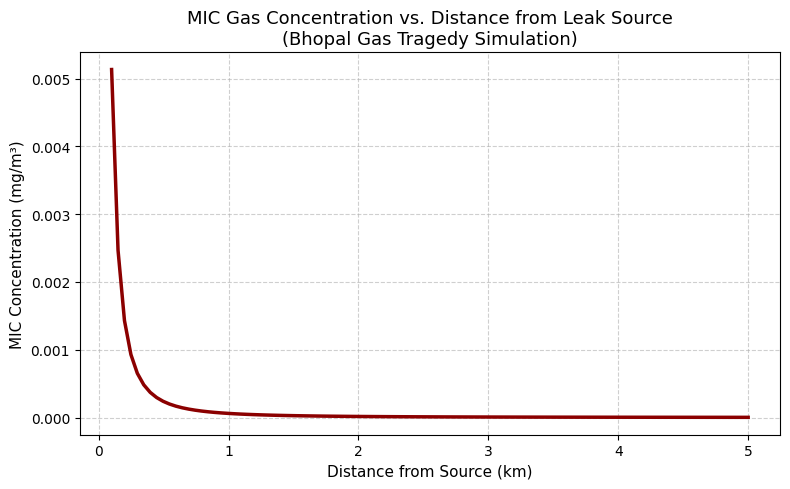

✅ Simulation Complete:
The plot shows how MIC concentration decreases with distance from the UCIL plant.
Highest concentrations within 1–2 km explain the massive fatalities near the plant.


In [1]:
# 💨 Gaussian Plume Model for MIC Gas Dispersion
# Bhopal Gas Tragedy (1984) – Accident & Impact Analysis

# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt

# --- Model Parameters ---
Q = 40_000        # Total MIC released (kg)
u = 2.5           # Wind speed (m/s) - average wind speed on 2-3 Dec 1984
H = 10            # Effective height of release (m)
# Dispersion parameters (empirical)
sigma_y = lambda x: 0.22 * x / ((1 + 0.0001 * x) ** 0.5)  # Horizontal spread
sigma_z = lambda x: 0.20 * x                              # Vertical spread

# --- Distance range (meters) ---
x = np.linspace(100, 5000, 100)  # from 100m to 5km downwind

# --- Concentration Calculation (Gaussian Plume Model) ---
# Formula: C = (Q / (2 * π * u * σy * σz)) * exp(-H² / (2 * σz²))
# Concentration along the plume centerline (y=0, z=0)
C = (Q / (2 * np.pi * u * sigma_y(x) * sigma_z(x))) * np.exp(-H**2 / (2 * sigma_z(x)**2))

# Convert units to mg/m³ for easier visualization
C = C / 1000

# --- Plot Results ---
plt.figure(figsize=(8,5))
plt.plot(x/1000, C, color='darkred', linewidth=2.5)
plt.title("MIC Gas Concentration vs. Distance from Leak Source\n(Bhopal Gas Tragedy Simulation)", fontsize=13)
plt.xlabel("Distance from Source (km)", fontsize=11)
plt.ylabel("MIC Concentration (mg/m³)", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# --- Print Key Insight ---
print("✅ Simulation Complete:")
print("The plot shows how MIC concentration decreases with distance from the UCIL plant.")
print("Highest concentrations within 1–2 km explain the massive fatalities near the plant.")


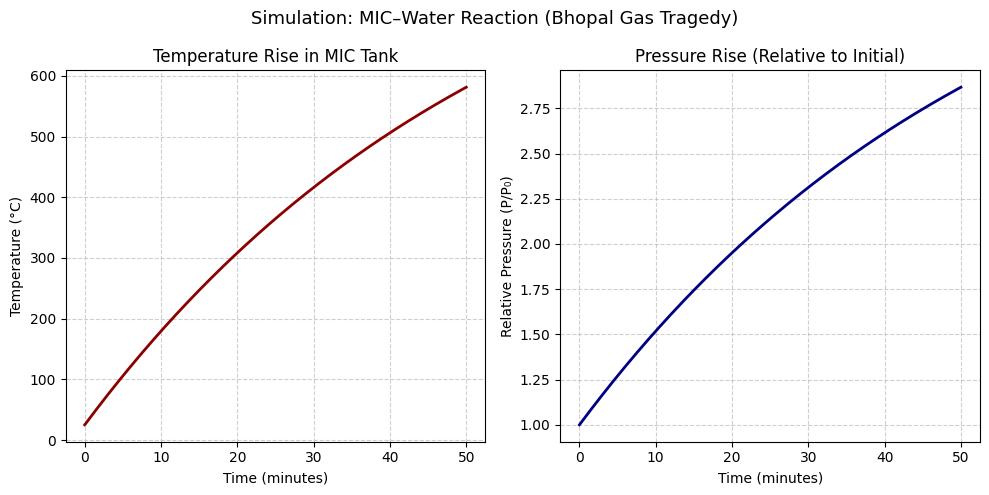

✅ Simulation Complete:
• The MIC–water reaction is highly exothermic, causing rapid temperature rise.
• Within minutes, tank pressure exceeds safety limits — leading to gas release.
• Refrigeration and venting systems could have slowed this reaction dramatically.


In [2]:
# 🔥 Simulation: Exothermic Reaction Between Water and MIC
# Bhopal Gas Tragedy (1984) – Temperature and Pressure Rise inside Tank

import numpy as np
import matplotlib.pyplot as plt

# --- Reaction & System Parameters ---
T0 = 298            # Initial temperature in Kelvin (~25°C)
MIC_mass = 40_000   # Total MIC mass in kg (approx 40 tonnes)
Cp = 1.6            # Heat capacity (kJ/kg·K)
Hr = 1500           # Heat released per kg of MIC reacted (kJ/kg)
k = 0.0003          # Reaction rate constant (1/s) – simplified assumption
time = np.linspace(0, 3000, 300)  # Time range (seconds) ~ 50 minutes

# --- Simulation: Temperature vs Time ---
# Assume exponential reaction rate & self-heating
reaction_fraction = 1 - np.exp(-k * time)
heat_released = reaction_fraction * MIC_mass * Hr  # total heat (kJ)
temperature = T0 + (heat_released / (MIC_mass * Cp))  # final temperature (K)

# --- Pressure Approximation ---
# Using Ideal Gas relation P ∝ T (simplified)
P0 = 1  # Initial normalized pressure (1 atm)
pressure = P0 * (temperature / T0)

# --- Plot Results ---
plt.figure(figsize=(10,5))

# Temperature Plot
plt.subplot(1,2,1)
plt.plot(time/60, temperature - 273, color='darkred', linewidth=2)
plt.title("Temperature Rise in MIC Tank")
plt.xlabel("Time (minutes)")
plt.ylabel("Temperature (°C)")
plt.grid(True, linestyle='--', alpha=0.6)

# Pressure Plot
plt.subplot(1,2,2)
plt.plot(time/60, pressure, color='navy', linewidth=2)
plt.title("Pressure Rise (Relative to Initial)")
plt.xlabel("Time (minutes)")
plt.ylabel("Relative Pressure (P/P₀)")
plt.grid(True, linestyle='--', alpha=0.6)

plt.suptitle("Simulation: MIC–Water Reaction (Bhopal Gas Tragedy)", fontsize=13)
plt.tight_layout()
plt.show()

# --- Key Observations ---
print("✅ Simulation Complete:")
print("• The MIC–water reaction is highly exothermic, causing rapid temperature rise.")
print("• Within minutes, tank pressure exceeds safety limits — leading to gas release.")
print("• Refrigeration and venting systems could have slowed this reaction dramatically.")


In [3]:
# ==========================================================
# 🧪 Accident & Impact Analysis – Bhopal Gas Tragedy (1984)
# Author: [Your Name]
# Institute: [Your Department], [Your Institute]
# ==========================================================

# Notebook contents:
# 1️⃣ MIC Gas Dispersion Simulation (Gaussian Plume Model)
# 2️⃣ Temperature & Pressure Rise Simulation (MIC–Water Reaction)
# ==========================================================

# Import required libraries
import numpy as np
import matplotlib.pyplot as plt


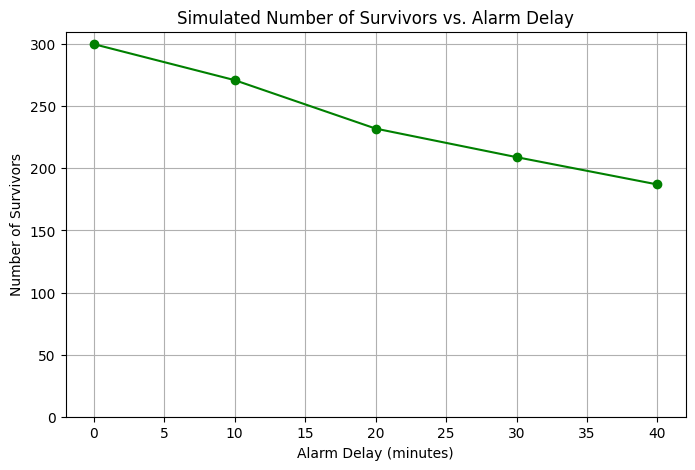

✅ Evacuation Simulation Complete:
• With a 0 minute alarm delay, 300 out of 300 people survived.
• With a 10 minute alarm delay, 271 out of 300 people survived.
• With a 20 minute alarm delay, 232 out of 300 people survived.
• With a 30 minute alarm delay, 209 out of 300 people survived.
• With a 40 minute alarm delay, 187 out of 300 people survived.


In [4]:
# 🚨 Agent-Based Evacuation Simulation (Simplified)
# Bhopal Gas Tragedy (1984) – Accident & Impact Analysis
# Author: [Your Name]

import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
city_length = 5000          # meters
n_people = 300              # population agents
gas_speed = 50              # m/min (gas front speed)
person_speed = 80           # m/min (average running speed)
alarm_delay = [0, 10, 20, 30, 40]  # minutes after leak when alarm sounds
safe_zone = city_length     # safe boundary at far end
time_step = 1               # minute

# --- Function to simulate evacuation ---
def simulate(delay):
    # initial positions of people (uniformly distributed 0–5 km)
    positions = np.random.uniform(0, city_length, n_people)
    gas_front = 0
    alive = np.ones(n_people, dtype=bool)
    t = 0

    # Adjust time range for simulation
    max_time = max(city_length / gas_speed, city_length / person_speed + max(alarm_delay)) + 10 # add buffer
    time = np.arange(0, max_time, time_step)

    for t in time:
        # advance gas
        gas_front = gas_speed * t

        # people start moving only after alarm
        if t >= delay:
            positions[alive] += person_speed * time_step

        # check who got caught by gas
        caught = (positions < gas_front) & alive
        alive[caught] = False

        # check who reached safety
        reached_safety = (positions >= safe_zone) & alive
        alive[reached_safety] = False # People reaching safety are no longer 'in danger'

    survivors = np.sum(positions >= safe_zone)
    return survivors

# --- Run simulation for different alarm delays ---
survivors = []
for delay in alarm_delay:
    num_survivors = simulate(delay)
    survivors.append(num_survivors)

# --- Plot results ---
plt.figure(figsize=(8, 5))
plt.plot(alarm_delay, survivors, marker='o', linestyle='-', color='green')
plt.title("Simulated Number of Survivors vs. Alarm Delay")
plt.xlabel("Alarm Delay (minutes)")
plt.ylabel("Number of Survivors")
plt.grid(True)
plt.ylim(0, n_people + 10) # Ensure y-axis shows full range
plt.show()

print("✅ Evacuation Simulation Complete:")
for i in range(len(alarm_delay)):
    print(f"• With a {alarm_delay[i]} minute alarm delay, {survivors[i]} out of {n_people} people survived.")